In [1]:
# Cell 1: Set Global Random Seeds & Imports
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
import requests
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, Bidirectional, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.utils import resample # For upsampling

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
print(f"Global random seeds set to {SEED}")

Global random seeds set to 42


# Predicting MOs LFP Activity from VISp LFP Data using LSTMs

This notebook aims to:
1. Load Steinmetz dataset (LFP and behavioral data for all sessions).
2. Incorporate mouse name and categorize mice as "Younger" (<= 20 weeks) or "Older" (> 20 weeks).
3. Preprocess VISp LFP data (X) and MOs LFP data (Y).
   - X (VISp LFP) will be from a window relative to stimulus onset.
   - Y (MOs LFP activity) will be from a window 100ms before to 100ms after response time.
4. Optionally upsample data for "Older" mice if there's an imbalance.
5. Train a Bidirectional LSTM model to predict MOs activity (or its PCA components) from VISp activity using GroupKFold cross-validation (grouped by session).
6. Evaluate model performance (MSE, MAE) globally and separately for "Younger" vs. "Older" mice.

In [2]:
# Cell 2: Configuration
PROCESSED_DATA_DIR = os.path.join(os.getcwd(), 'steinmetz_data_downloads')
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
print(f"Data will be downloaded/loaded from: {PROCESSED_DATA_DIR}")

TARGET_BRAIN_REGION_X = 'VISp' # Input features from VISp
TARGET_BRAIN_REGION_Y = 'MOs'  # Target variable from MOs (e.g., MOs, MOp)

# Time window for VISp LFP data (X), relative to stimulus onset (or alternative event like go-cue)
X_TIME_WINDOW_START_POST_EVENT_MS = 0 
X_TIME_WINDOW_END_POST_EVENT_MS = 500 

# Time window for MOs LFP data (Y), relative to response_time
Y_TIME_WINDOW_BEFORE_RESPONSE_MS = 100 
Y_TIME_WINDOW_AFTER_RESPONSE_MS = 100 
# Y_TIME_WINDOW_AROUND_RESPONSE_MS = 100 # This variable was unused

# LSTM Hyperparameters
N_EPOCHS = 100 
BATCH_SIZE = 64
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DENSE_UNITS_REG = 64 
DROPOUT_RATE = 0.3
LEARNING_RATE = 0.001 
N_SPLITS_CV = 5
EARLY_STOPPING_PATIENCE = 20 # Increased patience

# PCA Configuration 
APPLY_PCA_X = True
N_PCA_COMPONENTS_X = 10 # For VISp features
APPLY_PCA_Y = True # Whether to apply PCA to MOs LFP target
N_PCA_COMPONENTS_Y = 5  # For MOs target, if APPLY_PCA_Y is True. This will be the output dimension of the model.

# Upsampling Configuration
APPLY_UPSAMPLING = True

Data will be downloaded/loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [3]:
# Cell 3: Mouse Metadata (Name, Age, Category)
mouse_info_steinmetz = {
    'Cori': {'sessions': [0], 'age_weeks': 11},
    'Lederberg': {'sessions': [11, 13], 'age_weeks': 15},
    'Tatum': {'sessions': [], 'age_weeks': 15}, # Will attempt to match by name from dataset if session not listed
    'Muller': {'sessions': [21], 'age_weeks': 17},
    'Radnitz': {'sessions': [24, 25], 'age_weeks': 20},
    'Richards': {'sessions': [], 'age_weeks': 26},
    'Forssmann': {'sessions': [3], 'age_weeks': 26},
    'Moniz': {'sessions': [], 'age_weeks': 30},
    'Hench': {'sessions': [7], 'age_weeks': 31},
    'Theiler': {'sessions': [38], 'age_weeks': 46}
    # Add other mice from dataset if necessary
}

# Populate category based on age
for name, data in mouse_info_steinmetz.items():
    data['category'] = 'Younger' if data['age_weeks'] <= 20 else 'Older'

# Create a direct mapping from session_idx to known mouse_name if explicitly listed
session_idx_to_mouse_name_map = {}
for name, data in mouse_info_steinmetz.items():
    for session_id in data['sessions']:
        session_idx_to_mouse_name_map[session_id] = name

def get_mouse_details_by_session(session_idx, session_main_data_dict):
    # Try to get mouse_name from session_idx map first
    mouse_name = session_idx_to_mouse_name_map.get(session_idx)
    
    if mouse_name and mouse_name in mouse_info_steinmetz:
        age = mouse_info_steinmetz[mouse_name]['age_weeks']
        category = mouse_info_steinmetz[mouse_name]['category']
        return mouse_name, age, category
        
    # Fallback: try to use 'mouse_name' field from the session_main_data_dict
    mouse_name_from_data = session_main_data_dict.get('mouse_name')
    if mouse_name_from_data and mouse_name_from_data in mouse_info_steinmetz:
        age = mouse_info_steinmetz[mouse_name_from_data]['age_weeks']
        category = mouse_info_steinmetz[mouse_name_from_data]['category']
        return mouse_name_from_data, age, category

    unmapped_name = mouse_name_from_data if mouse_name_from_data else f'UnknownSession_{session_idx}'
    # print(f"Warning: Mouse for session {session_idx} (Name: {unmapped_name}) not found in metadata or explicit map.")
    return unmapped_name, -1, 'Unknown' # Age -1 for unknown

print("Mouse metadata and helper functions defined.")
print(f"Session_id to Mouse_name Mapping (explicit): {session_idx_to_mouse_name_map}")

Mouse metadata and helper functions defined.
Session_id to Mouse_name Mapping (explicit): {0: 'Cori', 11: 'Lederberg', 13: 'Lederberg', 21: 'Muller', 24: 'Radnitz', 25: 'Radnitz', 3: 'Forssmann', 7: 'Hench', 38: 'Theiler'}


In [4]:
# Cell 4: Data Download and Loading (adapted from new_lfp_seed_cv.ipynb)
target_dir = PROCESSED_DATA_DIR

fname_parts_download = []
for j in range(3):
    fname_parts_download.append(os.path.join(target_dir, 'steinmetz_part%d.npz' % j))

urls_parts_download = [
    "https://osf.io/agvxh/download",
    "https://osf.io/uv3mw/download",
    "https://osf.io/ehmw2/download",
]

fname_lfp_download = os.path.join(target_dir, 'steinmetz_lfp.npz')
url_lfp_download = "https://osf.io/kx3v9/download"

all_fnames_to_download = fname_parts_download + [fname_lfp_download]
all_urls_to_download = urls_parts_download + [url_lfp_download]

print("Starting download process...")
for i in range(len(all_fnames_to_download)):
    fname_current = all_fnames_to_download[i]
    url_current = all_urls_to_download[i]
    
    if os.path.isfile(fname_current):
        file_size_mb_check = os.path.getsize(fname_current) / (1024 * 1024)
        if file_size_mb_check > 10: 
             print(f"File {os.path.basename(fname_current)} already exists and seems complete (Size: {file_size_mb_check:.2f} MB). Skipping download.")
             continue
        else:
            print(f"File {os.path.basename(fname_current)} exists (Size: {file_size_mb_check:.2f} MB), but might be small. Re-downloading.")

    print(f"Downloading {os.path.basename(fname_current)} from {url_current}...")
    try:
        r = requests.get(url_current, timeout=300) 
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"!!! Failed to download {os.path.basename(fname_current)} from {url_current}: {e} !!! Skipping this file.")
        continue
    else:
        with open(fname_current, "wb") as fid:
            fid.write(r.content)
        file_size_mb = os.path.getsize(fname_current) / (1024 * 1024)
        print(f"Successfully downloaded {os.path.basename(fname_current)}. Size: {file_size_mb:.2f} MB")
print("Download process complete.")

alldat = []
main_npz_files_to_load = [os.path.join(target_dir, 'steinmetz_part%d.npz' % j) for j in range(3)]

print(f"\nLoading main data (steinmetz_part*.npz files) from {target_dir}:")
for f_path in main_npz_files_to_load:
    f_name = os.path.basename(f_path)
    if not os.path.isfile(f_path):
        print(f"Error: Main data file {f_name} not found in {target_dir}. Halting.")
        raise FileNotFoundError(f"Required main data file {f_name} is missing. Cannot proceed.")
    print(f"  - Loading {f_name}...")
    try:
        data_part = np.load(f_path, allow_pickle=True)
        if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)):
            if len(data_part['dat']) > 0 and isinstance(data_part['dat'][0], dict):
                alldat.extend(data_part['dat'])
            else:
                 print(f"Warning: 'dat' in {f_name} is not a list/array of dictionaries as expected.")
        else:
            print(f"Warning: File {f_name} does not contain a 'dat' key, or 'dat' is not a list/array.")
    except Exception as e:
        print(f"Critical error loading {f_name}: {e}")
        raise

if not alldat:
    raise ValueError("No main session data could be loaded. Check downloads and PROCESSED_DATA_DIR.")
print(f"Successfully loaded main data for {len(alldat)} sessions.")

lfp_file_path_load = os.path.join(target_dir, 'steinmetz_lfp.npz')
if not os.path.isfile(lfp_file_path_load):
    raise FileNotFoundError(f"'steinmetz_lfp.npz' not found in {target_dir}. Please ensure it was downloaded correctly.")

print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path_load)}...")
try:
    dat_LFP_all_sessions_raw = np.load(lfp_file_path_load, allow_pickle=True)['dat']
    if isinstance(dat_LFP_all_sessions_raw, np.ndarray) and dat_LFP_all_sessions_raw.ndim == 1 and isinstance(dat_LFP_all_sessions_raw[0], dict):
        dat_LFP = list(dat_LFP_all_sessions_raw)
    elif isinstance(dat_LFP_all_sessions_raw, list) and len(dat_LFP_all_sessions_raw) > 0 and isinstance(dat_LFP_all_sessions_raw[0], dict):
        dat_LFP = dat_LFP_all_sessions_raw
    else:
        raise ValueError("'dat' key in LFP file is not in the expected format (list/array of dictionaries).")
    print(f"Successfully loaded LFP data for {len(dat_LFP)} sessions.")
except Exception as e:
    raise ValueError(f"Error loading 'steinmetz_lfp.npz': {e}")

if len(alldat) != len(dat_LFP):
    print(f"Warning: Number of main sessions ({len(alldat)}) does not match LFP sessions ({len(dat_LFP)}). Using the minimum count.")
    min_sessions = min(len(alldat), len(dat_LFP))
    alldat = alldat[:min_sessions]
    dat_LFP = dat_LFP[:min_sessions]
    print(f"Adjusted to {min_sessions} sessions for both main data and LFP data.")

Starting download process...
File steinmetz_part0.npz already exists and seems complete (Size: 83.49 MB). Skipping download.
File steinmetz_part1.npz already exists and seems complete (Size: 67.14 MB). Skipping download.
File steinmetz_part2.npz already exists and seems complete (Size: 61.13 MB). Skipping download.
File steinmetz_lfp.npz already exists and seems complete (Size: 150.36 MB). Skipping download.
Download process complete.

Loading main data (steinmetz_part*.npz files) from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Successfully loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Successfully loaded LFP data for 39 sessions.


## Data Preprocessing for Predicting MOs from VISp Activity

- Iterate through all loaded sessions.
- Get mouse name and determine age category (Younger/Older).
- **Extract VISp LFP (X):** From `X_TIME_WINDOW_START_POST_STIM_MS` to `X_TIME_WINDOW_END_POST_STIM_MS` relative to stimulus onset. Apply PCA if `APPLY_PCA_X`.
- **Extract MOs LFP (Y):** From `response_time - Y_TIME_WINDOW_BEFORE_RESPONSE_MS` to `response_time + Y_TIME_WINDOW_AFTER_RESPONSE_MS`. Apply PCA if `APPLY_PCA_Y`. 
The target will be the PCA components of this window.
- Handle trials with missing response times or invalid LFP windows.
- Align valid X and Y trials.\n- Accumulate X, Y, session IDs, and age categories.
- Perform global scaling on concatenated X data (and Y data if Y is multi-featured before final Dense layer)."

In [5]:
# Cell 5: Data Preprocessing for MOs LFP Prediction
all_X_data = [] # VISp LFP features
all_Y_data = [] # MOs LFP target (PCA components or raw averaged window)
all_session_ids = []
all_mouse_names = []
all_age_categories = []
all_trial_indices_original = [] 

print(f"Processing {len(alldat)} sessions...")

for session_idx in range(len(alldat)):
    session_data_main = alldat[session_idx]
    session_data_lfp = dat_LFP[session_idx]
    event_source_for_X = "stim_onset" # Default event source

    # --- Debug prints for the first session ---
    if session_idx == 0:
        print(f"\n--- Debugging Session {session_idx} ---")
        print(f"Keys in session_data_lfp: {list(session_data_lfp.keys())}")
        print(f"Keys in session_data_main: {list(session_data_main.keys())}")
        for key_to_debug in ['stim_onset', 'gocue', 'response_time', 'active_trials']:
            if key_to_debug in session_data_main:
                data_val = session_data_main[key_to_debug]
                print(f"Type of session_data_main['{key_to_debug}']: {type(data_val)}")
                if isinstance(data_val, np.ndarray):
                    print(f"Shape of session_data_main['{key_to_debug}']: {data_val.shape}")
                    print(f"Value of session_data_main['{key_to_debug}'] (first 5 if array): {data_val.squeeze()[:5] if data_val.ndim > 0 else data_val}")
                else:
                    print(f"Value of session_data_main['{key_to_debug}']: {data_val}")
            else:
                print(f"session_data_main is missing '{key_to_debug}' key.")
        if 'lfp' in session_data_lfp:
             print(f"LFP n_trials (from lfp_all_channels.shape[1]): {session_data_lfp['lfp'].shape[1]}")
        print(f"--------------------------------------")
    # --- End Debug prints ---

    mouse_name, mouse_age, age_category = get_mouse_details_by_session(session_idx, session_data_main)
    if age_category == 'Unknown':
        continue
        
    print(f'\n--- Processing Session {session_idx} (Mouse: {mouse_name}, Age: {mouse_age}w, Category: {age_category}) ---')
    
    required_lfp_keys = ['lfp', 'brain_area_lfp']
    if any(key not in session_data_lfp for key in required_lfp_keys):
        print(f'  Warning: Session {session_idx} missing LFP keys. Skipping.')
        continue
        
    required_main_keys = ['stim_onset', 'response_time', 'bin_size', 'gocue'] # Added gocue as potentially required
    if any(key not in session_data_main for key in required_main_keys):
        print(f'  Warning: Session {session_idx} missing main data keys (stim_onset, response_time, gocue, or bin_size). Skipping.')
        continue

    lfp_all_channels = session_data_lfp['lfp'] 
    lfp_brain_areas = np.array(session_data_lfp['brain_area_lfp'])
    dt_lfp_s = session_data_main['bin_size'] 
    n_trials_lfp = lfp_all_channels.shape[1]

    # Process response_times (always needed for Y)
    response_times_orig = session_data_main['response_time']
    response_times = np.asarray(response_times_orig).squeeze()
    if response_times.ndim == 0: response_times = np.array([response_times.item()])
    n_trials_resp = len(response_times)

    # Determine event_times_for_X (for aligning X features)
    event_times_for_X = None
    stim_onset_times_orig = session_data_main['stim_onset']
    stim_onset_times = np.asarray(stim_onset_times_orig).squeeze()
    if stim_onset_times.ndim == 0: stim_onset_times = np.array([stim_onset_times.item()])
    n_trials_stim = len(stim_onset_times)

    if n_trials_stim > 1 and (n_trials_stim == n_trials_lfp or n_trials_stim == n_trials_resp):
        event_times_for_X = stim_onset_times
        event_source_for_X = "stim_onset"
        print(f"  Using 'stim_onset' for X alignment ({n_trials_stim} events).")
    else:
        print(f"  'stim_onset' is scalar or count ({n_trials_stim}) mismatches LFP ({n_trials_lfp}) / Resp ({n_trials_resp}). Trying 'gocue'.")
        gocue_times_orig = session_data_main.get('gocue')
        if gocue_times_orig is not None:
            gocue_times = np.asarray(gocue_times_orig).squeeze()
            if gocue_times.ndim == 0: gocue_times = np.array([gocue_times.item()])
            n_trials_gocue = len(gocue_times)
            if n_trials_gocue > 1 and (n_trials_gocue == n_trials_lfp or n_trials_gocue == n_trials_resp):
                event_times_for_X = gocue_times
                event_source_for_X = "gocue"
                print(f"  Using 'gocue' for X alignment ({n_trials_gocue} events).")
            else:
                print(f"  'gocue' is also scalar or count ({n_trials_gocue}) mismatches. Skipping session {session_idx}.")
                continue
        else:
            print(f"  'gocue' not found. Skipping session {session_idx}.")
            continue
            
    if event_times_for_X is None: # Should be caught above, but as a safeguard
        print(f"  Error: No suitable event (stim_onset or gocue) found for X alignment. Skipping session {session_idx}.")
        continue

    n_trials_event_X = len(event_times_for_X)
    n_trials_session = min(n_trials_lfp, n_trials_event_X, n_trials_resp)

    if n_trials_session == 0:
        print(f'  Skipping session {session_idx}: Zero common trials (LFP: {n_trials_lfp}, EventX({event_source_for_X}): {n_trials_event_X}, Resp: {n_trials_resp}).')
        continue
        
    # Ensure all data streams are sliced to n_trials_session
    if n_trials_lfp != n_trials_session: lfp_all_channels = lfp_all_channels[:, :n_trials_session, :]
    if n_trials_event_X != n_trials_session: event_times_for_X = event_times_for_X[:n_trials_session]
    if n_trials_resp != n_trials_session: response_times = response_times[:n_trials_session]
    
    print(f"  Using {n_trials_session} trials for session {session_idx} based on {event_source_for_X}, LFP, and response_time alignment.")

    visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION_X)[0]
    if len(visp_channel_indices) == 0:
        print(f'  Warning: No LFP channels for {TARGET_BRAIN_REGION_X}. Skipping.')
        continue
    lfp_visp_all_trials = lfp_all_channels[visp_channel_indices, :, :] 
    
    x_start_s_rel_event = X_TIME_WINDOW_START_POST_EVENT_MS / 1000.0
    x_end_s_rel_event = X_TIME_WINDOW_END_POST_EVENT_MS / 1000.0
    
    mos_channel_indices = np.where(np.isin(lfp_brain_areas, [TARGET_BRAIN_REGION_Y, 'MOs', 'MOp']))[0]
    if len(mos_channel_indices) == 0:
        print(f'  Warning: No LFP channels for {TARGET_BRAIN_REGION_Y}. Skipping.')
        continue
    lfp_mos_all_trials = lfp_all_channels[mos_channel_indices, :, :] 
    
    y_window_before_s = Y_TIME_WINDOW_BEFORE_RESPONSE_MS / 1000.0
    y_window_after_s = Y_TIME_WINDOW_AFTER_RESPONSE_MS / 1000.0
    
    session_X_data_list = []
    session_Y_data_list = []
    session_trial_ids_list = []
    
    for trial_idx in range(n_trials_session): 
        event_t_x = event_times_for_X[trial_idx] # This is now from stim_onset or gocue
        response_t = response_times[trial_idx]
        
        if np.isnan(event_t_x) or np.isnan(response_t):
            continue
            
        x_window_start_abs_s = event_t_x + x_start_s_rel_event
        x_window_end_abs_s = event_t_x + x_end_s_rel_event
        x_start_lfp_idx = int(np.round(x_window_start_abs_s / dt_lfp_s))
        x_end_lfp_idx = int(np.round(x_window_end_abs_s / dt_lfp_s))
        
        if not (0 <= x_start_lfp_idx < x_end_lfp_idx <= lfp_visp_all_trials.shape[2]):
            continue
        x_trial_lfp = lfp_visp_all_trials[:, trial_idx, x_start_lfp_idx:x_end_lfp_idx]
        if x_trial_lfp.shape[1] == 0: continue
        
        y_window_start_abs_s = response_t - y_window_before_s
        y_window_end_abs_s = response_t + y_window_after_s
        y_start_lfp_idx = int(np.round(y_window_start_abs_s / dt_lfp_s))
        y_end_lfp_idx = int(np.round(y_window_end_abs_s / dt_lfp_s))
        
        if not (0 <= y_start_lfp_idx < y_end_lfp_idx <= lfp_mos_all_trials.shape[2]):
            continue
        y_trial_lfp = lfp_mos_all_trials[:, trial_idx, y_start_lfp_idx:y_end_lfp_idx]
        if y_trial_lfp.shape[1] == 0: continue

        session_X_data_list.append(x_trial_lfp.T) 
        session_Y_data_list.append(y_trial_lfp.T) 
        session_trial_ids_list.append(trial_idx)
        
    if not session_X_data_list: 
        print(f'  No valid trials processed for session {session_idx} after trial loop.')
        continue

    max_len_x = max(arr.shape[0] for arr in session_X_data_list)
    n_features_x_raw = session_X_data_list[0].shape[1]
    X_session_padded = np.array([np.pad(arr, ((0, max_len_x - arr.shape[0]), (0,0)), 'constant', constant_values=0) for arr in session_X_data_list])

    X_session_processed = X_session_padded
    if APPLY_PCA_X:
        if n_features_x_raw > N_PCA_COMPONENTS_X:
            pca_x = PCA(n_components=N_PCA_COMPONENTS_X, random_state=SEED)
            X_reshaped_for_pca = X_session_padded.reshape(-1, n_features_x_raw)
            X_pca_transformed = pca_x.fit_transform(X_reshaped_for_pca)
            X_session_processed = X_pca_transformed.reshape(X_session_padded.shape[0], max_len_x, N_PCA_COMPONENTS_X)
        elif n_features_x_raw < N_PCA_COMPONENTS_X: 
            X_temp_padded_pca = np.zeros((X_session_padded.shape[0], max_len_x, N_PCA_COMPONENTS_X))
            X_temp_padded_pca[:, :, :n_features_x_raw] = X_session_padded
            X_session_processed = X_temp_padded_pca
        # If n_features_x_raw == N_PCA_COMPONENTS_X, no change

    max_len_y = max(arr.shape[0] for arr in session_Y_data_list)
    n_features_y_raw = session_Y_data_list[0].shape[1]
    Y_session_padded_raw = np.array([np.pad(arr, ((0, max_len_y - arr.shape[0]), (0,0)), 'constant', constant_values=0) for arr in session_Y_data_list])
    
    Y_session_processed_target = Y_session_padded_raw 
    if APPLY_PCA_Y:
        if n_features_y_raw > N_PCA_COMPONENTS_Y:
            pca_y = PCA(n_components=N_PCA_COMPONENTS_Y, random_state=SEED)
            Y_reshaped_for_pca = Y_session_padded_raw.reshape(-1, n_features_y_raw)
            Y_pca_transformed = pca_y.fit_transform(Y_reshaped_for_pca)
            Y_session_final_timesteps = Y_pca_transformed.reshape(Y_session_padded_raw.shape[0], max_len_y, N_PCA_COMPONENTS_Y)
            Y_session_processed_target = np.mean(Y_session_final_timesteps, axis=1) 
        elif n_features_y_raw < N_PCA_COMPONENTS_Y: 
            Y_temp_padded_pca = np.zeros((Y_session_padded_raw.shape[0], max_len_y, N_PCA_COMPONENTS_Y))
            Y_temp_padded_pca[:, :, :n_features_y_raw] = Y_session_padded_raw
            Y_session_processed_target = np.mean(Y_temp_padded_pca, axis=1) 
        elif n_features_y_raw == N_PCA_COMPONENTS_Y: # Added this condition for completeness
             Y_session_processed_target = np.mean(Y_session_padded_raw, axis=1) 
    else: 
        Y_session_processed_target = np.mean(Y_session_padded_raw, axis=2) 
        Y_session_processed_target = np.mean(Y_session_processed_target, axis=1).reshape(-1,1) 
            
    if X_session_processed.shape[0] == 0 or Y_session_processed_target.shape[0] == 0:
        print(f'  Session {session_idx} resulted in empty X or Y after PCA/padding. Skipping.')
        continue
        
    all_X_data.append(X_session_processed)
    all_Y_data.append(Y_session_processed_target)
    num_valid_trials_session = X_session_processed.shape[0]
    all_session_ids.extend([session_idx] * num_valid_trials_session)
    all_mouse_names.extend([mouse_name] * num_valid_trials_session)
    all_age_categories.extend([age_category] * num_valid_trials_session)
    all_trial_indices_original.extend(session_trial_ids_list) 

    print(f'  Session {session_idx}: Added {num_valid_trials_session} trials. X shape: {X_session_processed.shape}, Y shape: {Y_session_processed_target.shape}')

if not all_X_data:
    raise ValueError("No data collected from any session. Check preprocessing logic, brain region names, windowing, and suitability of 'stim_onset' or 'gocue' for X alignment.")

X_combined = np.concatenate(all_X_data, axis=0)
Y_combined = np.concatenate(all_Y_data, axis=0) 
groups = np.array(all_session_ids)
mouse_names_arr = np.array(all_mouse_names)
age_categories_arr = np.array(all_age_categories)

print(f'\nShape of X_combined before scaling: {X_combined.shape}')
print(f'Shape of Y_combined: {Y_combined.shape}')
print(f'Shape of groups: {groups.shape}')
print(f'Shape of mouse_names_arr: {mouse_names_arr.shape}')
print(f'Shape of age_categories_arr: {age_categories_arr.shape}')

# Global Scaling for X features
if X_combined.size > 0: # Check if X_combined is not empty
    n_trials_total_x, n_timesteps_x, n_features_x = X_combined.shape
    if n_features_x > 0: # Check if there are features to scale
        X_reshaped = X_combined.reshape(-1, n_features_x)
        global_x_scaler = StandardScaler()
        X_scaled_reshaped = global_x_scaler.fit_transform(X_reshaped)
        X_final = X_scaled_reshaped.reshape(n_trials_total_x, n_timesteps_x, n_features_x)
    else: # Handle case with no features
        print("Warning: X_combined has no features. Using unscaled X_combined.")
        X_final = X_combined # Or handle as an error
else: # Handle case with no trials
    print("Warning: X_combined is empty. No scaling applied.")
    X_final = X_combined # Or handle as an error

print(f'Shape of final X after scaling: {X_final.shape}')


Y_final = Y_combined 
print(f'Shape of final Y: {Y_final.shape}')

unique_categories, counts = np.unique(age_categories_arr, return_counts=True)
print('\nTrial counts per age category:')
for category, count in zip(unique_categories, counts):
    print(f'  {category}: {count}')

if X_final.shape[0] > 0:
    print(f'Total valid trials: {X_final.shape[0]}')
else:
    print('Total valid trials: 0')

Processing 39 sessions...

--- Debugging Session 0 ---
Keys in session_data_lfp: ['lfp', 'lfp_passive', 'brain_area_lfp']
Keys in session_data_main: ['spks', 'wheel', 'pupil', 'response', 'response_time', 'bin_size', 'stim_onset', 'contrast_right', 'contrast_left', 'brain_area', 'feedback_time', 'feedback_type', 'gocue', 'mouse_name', 'date_exp', 'trough_to_peak', 'active_trials', 'contrast_left_passive', 'contrast_right_passive', 'spks_passive', 'pupil_passive', 'wheel_passive', 'prev_reward', 'ccf', 'ccf_axes', 'cellid_orig', 'reaction_time', 'face', 'face_passive', 'licks', 'licks_passive']
Type of session_data_main['stim_onset']: <class 'float'>
Value of session_data_main['stim_onset']: 0.5
Type of session_data_main['gocue']: <class 'numpy.ndarray'>
Shape of session_data_main['gocue']: (214, 1)
Value of session_data_main['gocue'] (first 5 if array): [1.02721625 0.87441381 0.82521303 0.76161202 0.66201043]
Type of session_data_main['response_time']: <class 'numpy.ndarray'>
Shape of 

## Upsampling (Optional)

In [6]:
# Cell 6: Upsampling Logic for Older Mice (if APPLY_UPSAMPLING is True)
# This will be applied *inside* the cross-validation loop to the training data only.
# Here we just define the function.
def upsample_minority_age_group(X_fold_train, Y_fold_train, age_categories_fold_train, mouse_names_fold_train, groups_fold_train):
    if not APPLY_UPSAMPLING:
        return X_fold_train, Y_fold_train, age_categories_fold_train, mouse_names_fold_train, groups_fold_train
    
    younger_indices = [i for i, cat in enumerate(age_categories_fold_train) if cat == 'Younger']
    older_indices = [i for i, cat in enumerate(age_categories_fold_train) if cat == 'Older']
    
    n_younger = len(younger_indices)
    n_older = len(older_indices)
    
    if n_older == 0 or n_younger == 0: # Cannot upsample if one class is missing
        print("  Upsampling skipped: one age category has no samples in this fold.")
        return X_fold_train, Y_fold_train, age_categories_fold_train, mouse_names_fold_train, groups_fold_train
        
    if n_older < n_younger:
        print(f"  Upsampling Older mice: from {n_older} to {n_younger} samples (by repetition).")
        X_older = X_fold_train[older_indices]
        Y_older = Y_fold_train[older_indices]
        age_older = age_categories_fold_train[older_indices]
        names_older = mouse_names_fold_train[older_indices]
        groups_older = groups_fold_train[older_indices]
        
        X_older_upsampled, Y_older_upsampled, age_older_upsampled, names_older_upsampled, groups_older_upsampled = resample(
            X_older, Y_older, age_older, names_older, groups_older, 
            replace=True, n_samples=n_younger, random_state=SEED
        )
        
        X_fold_train_upsampled = np.concatenate((X_fold_train[younger_indices], X_older_upsampled))
        Y_fold_train_upsampled = np.concatenate((Y_fold_train[younger_indices], Y_older_upsampled))
        age_cat_train_upsampled = np.concatenate((age_categories_fold_train[younger_indices], age_older_upsampled))
        names_train_upsampled = np.concatenate((mouse_names_fold_train[younger_indices], names_older_upsampled))
        groups_train_upsampled = np.concatenate((groups_fold_train[younger_indices], groups_older_upsampled))
        
        # Shuffle the upsampled training data
        shuffle_indices = np.random.permutation(len(X_fold_train_upsampled))
        return X_fold_train_upsampled[shuffle_indices], Y_fold_train_upsampled[shuffle_indices], age_cat_train_upsampled[shuffle_indices], names_train_upsampled[shuffle_indices], groups_train_upsampled[shuffle_indices]
    else:
        print("  Upsampling not needed or Older group is larger/equal.")
        return X_fold_train, Y_fold_train, age_categories_fold_train, mouse_names_fold_train, groups_fold_train

print("Upsampling function defined.")

Upsampling function defined.


## Model Definition, Cross-Validation, Training, and Evaluation

Input shape for model: (50, 10)
Output dimension for model: 5

--- FOLD 1/5 ---
  Upsampling Older mice: from 727 to 1182 samples (by repetition).
  X_train_fold shape (after upsampling): (2364, 50, 10), Y_train_fold shape (after upsampling): (2364, 5)
  X_val_fold shape: (389, 50, 10), Y_val_fold shape: (389, 5)
  Unique groups in training data for fold 1: [ 0  3  7 11 13 24 25 38]
  Unique groups in validation data for fold 1: [21]


Model: "bidirectional_lstm_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_reg (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,805 (1.21 MB)

 Trainable params: 316,037 (1.21 MB)

 Non-trainable params: 768 (3.00 KB)

Training model for fold 1...
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 11.7879 - mean_absolute_error: 1.8500 - mean_squared_error: 11.7879 - val_loss: 7.4041 - val_mean_absolute_error: 0.8091 - val_mean_squared_error: 7.4041
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 10.8281 - mean_absolute_error: 1.6204 - mean_squared_error: 10.8281 - val_loss: 7.3985 - val_mean_absolute_error: 0.8129 - val_mean_squared_error: 7.3985
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 10.3720 - mean_absolute_error: 1.5328 - mean_squared_error: 10.3720 - val_loss: 7.2154 - val_mean_absolute_error: 0.8245 - val_mean_squared_error: 7.2154
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 10.2614 - mean_absolute_error: 1.4713 - mean_squared_error: 10.2614 - val_loss: 7.3142 - val_mean_absolute_error: 0.8253 - val_mean_squared_error: 7.3142
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 10.2185 - mean_absolute_error: 1.4148 - mean_squared_er

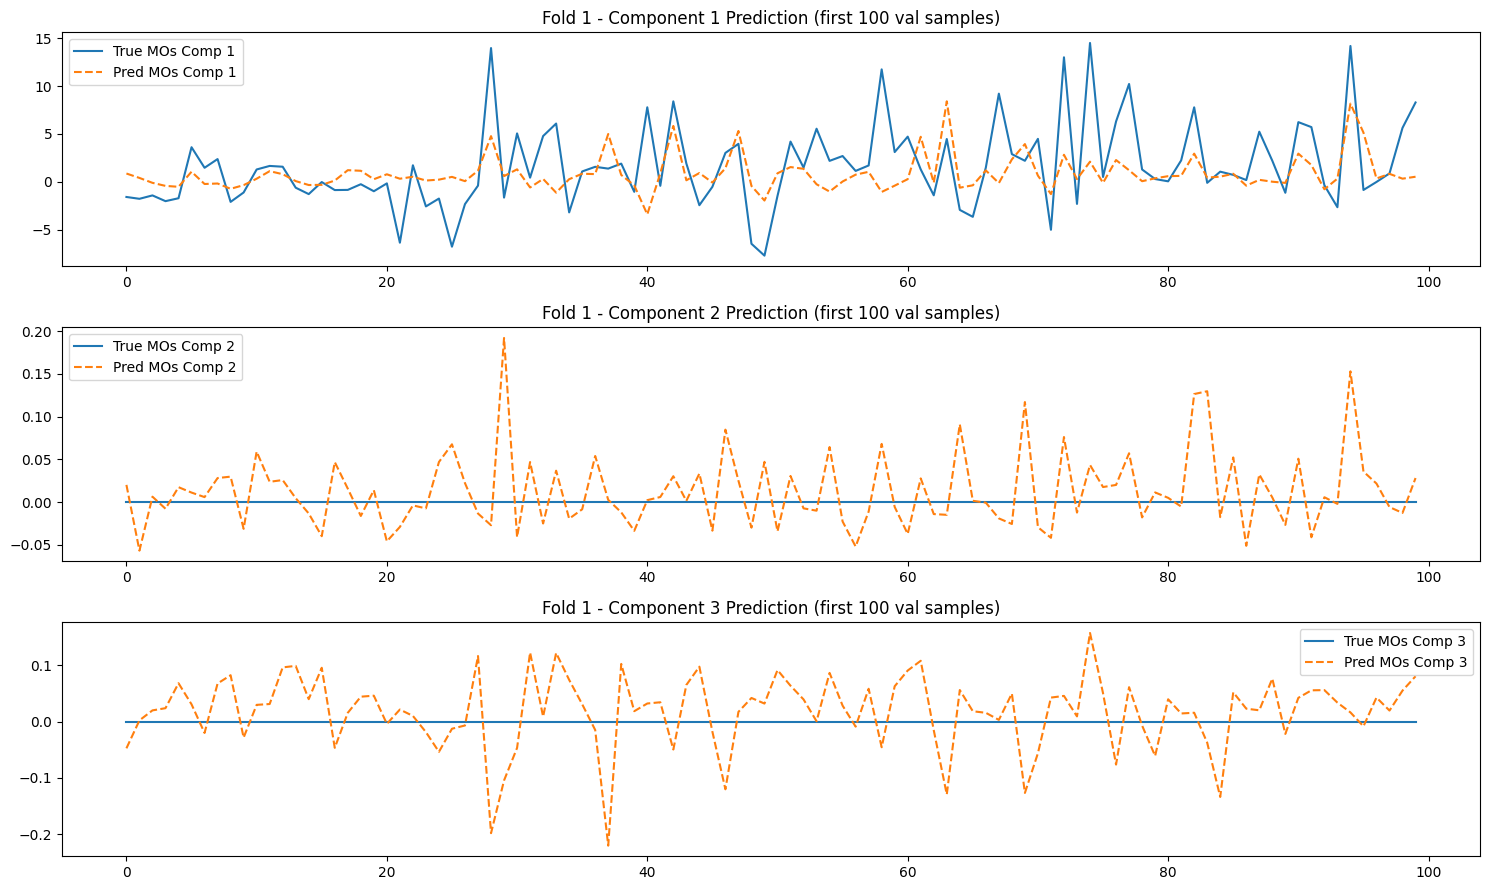


--- FOLD 2/5 ---
  Upsampling Older mice: from 384 to 1412 samples (by repetition).
  X_train_fold shape (after upsampling): (2824, 50, 10), Y_train_fold shape (after upsampling): (2824, 5)
  X_val_fold shape: (502, 50, 10), Y_val_fold shape: (502, 5)
  Unique groups in training data for fold 2: [ 0  3  7 11 13 21 24]
  Unique groups in validation data for fold 2: [25 38]


Model: "bidirectional_lstm_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_reg (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,805 (1.21 MB)

 Trainable params: 316,037 (1.21 MB)

 Non-trainable params: 768 (3.00 KB)

Training model for fold 2...
Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 11.3268 - mean_absolute_error: 1.7850 - mean_squared_error: 11.3268 - val_loss: 6.4337 - val_mean_absolute_error: 0.9250 - val_mean_squared_error: 6.4337
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 10.2424 - mean_absolute_error: 1.5468 - mean_squared_error: 10.2424 - val_loss: 6.4650 - val_mean_absolute_error: 0.9233 - val_mean_squared_error: 6.4650
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 9.9069 - mean_absolute_error: 1.4680 - mean_squared_error: 9.9069 - val_loss: 6.4587 - val_mean_absolute_error: 0.9321 - val_mean_squared_error: 6.4587
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 9.8143 - mean_absolute_error: 1.3957 - mean_squared_error: 9.8143 - val_loss: 6.4634 - val_mean_absolute_error: 0.9470 - val_mean_squared_error: 6.4634
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 9.7146 - mean_absolute_error: 1.3563 - mean_squared_error: 

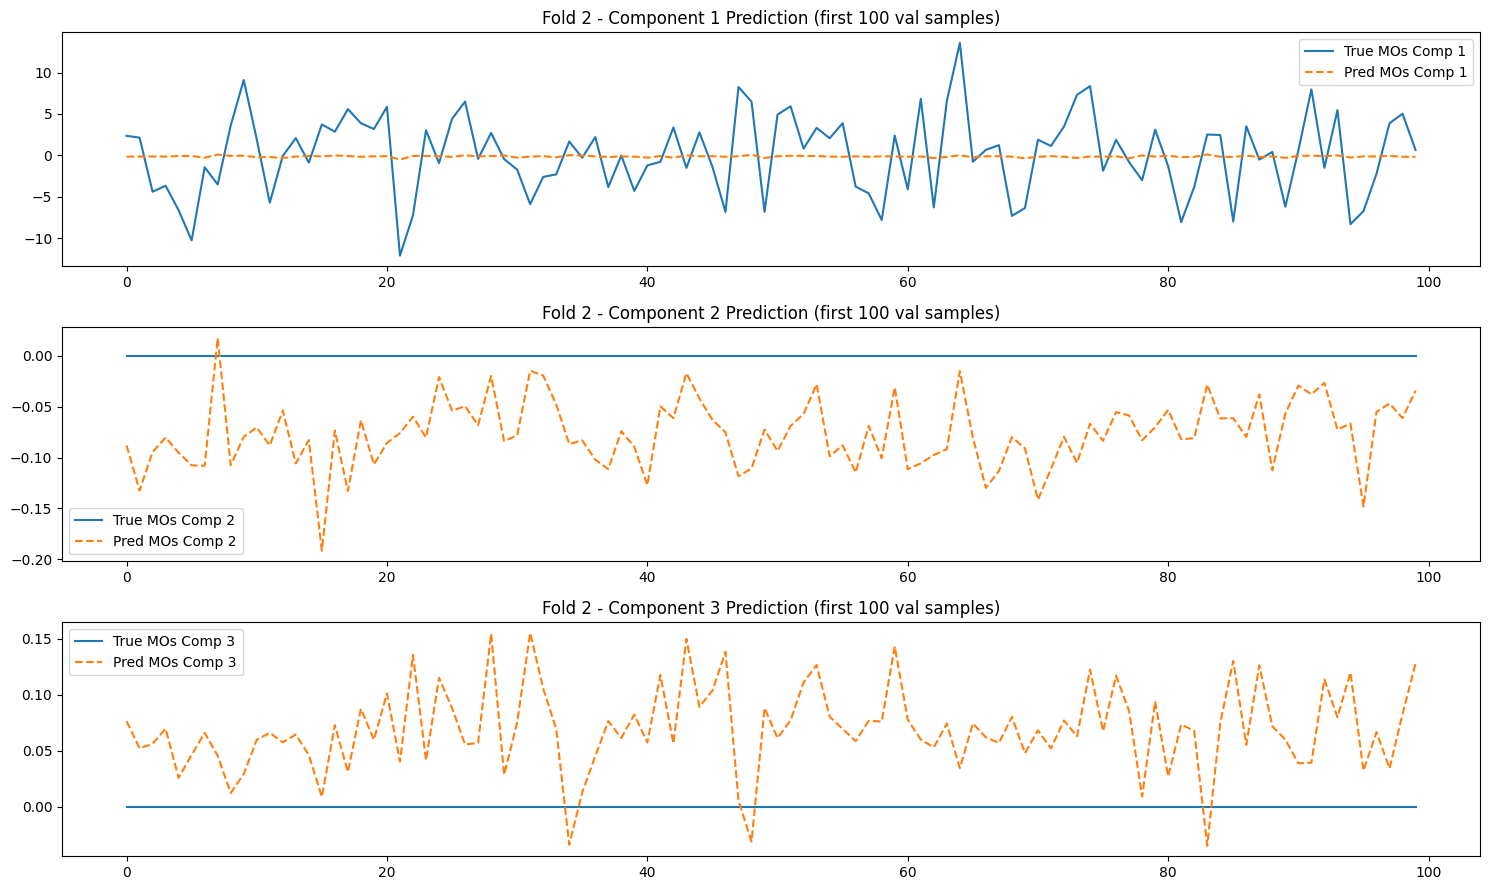


--- FOLD 3/5 ---
  Upsampling Older mice: from 548 to 1231 samples (by repetition).
  X_train_fold shape (after upsampling): (2462, 50, 10), Y_train_fold shape (after upsampling): (2462, 5)
  X_val_fold shape: (519, 50, 10), Y_val_fold shape: (519, 5)
  Unique groups in training data for fold 3: [ 0  7 13 21 24 25 38]
  Unique groups in validation data for fold 3: [ 3 11]


Model: "bidirectional_lstm_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_reg (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,805 (1.21 MB)

 Trainable params: 316,037 (1.21 MB)

 Non-trainable params: 768 (3.00 KB)

Training model for fold 3...
Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 9.0143 - mean_absolute_error: 1.6927 - mean_squared_error: 9.0143 - val_loss: 13.8612 - val_mean_absolute_error: 1.2196 - val_mean_squared_error: 13.8612
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 8.0127 - mean_absolute_error: 1.4464 - mean_squared_error: 8.0127 - val_loss: 13.7607 - val_mean_absolute_error: 1.2236 - val_mean_squared_error: 13.7607
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 7.9244 - mean_absolute_error: 1.3852 - mean_squared_error: 7.9244 - val_loss: 13.7052 - val_mean_absolute_error: 1.2179 - val_mean_squared_error: 13.7052
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 7.7561 - mean_absolute_error: 1.3110 - mean_squared_error: 7.7561 - val_loss: 13.4277 - val_mean_absolute_error: 1.2063 - val_mean_squared_error: 13.4277
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 7.5554 - mean_absolute_error: 1.2605 - mean_squared_err

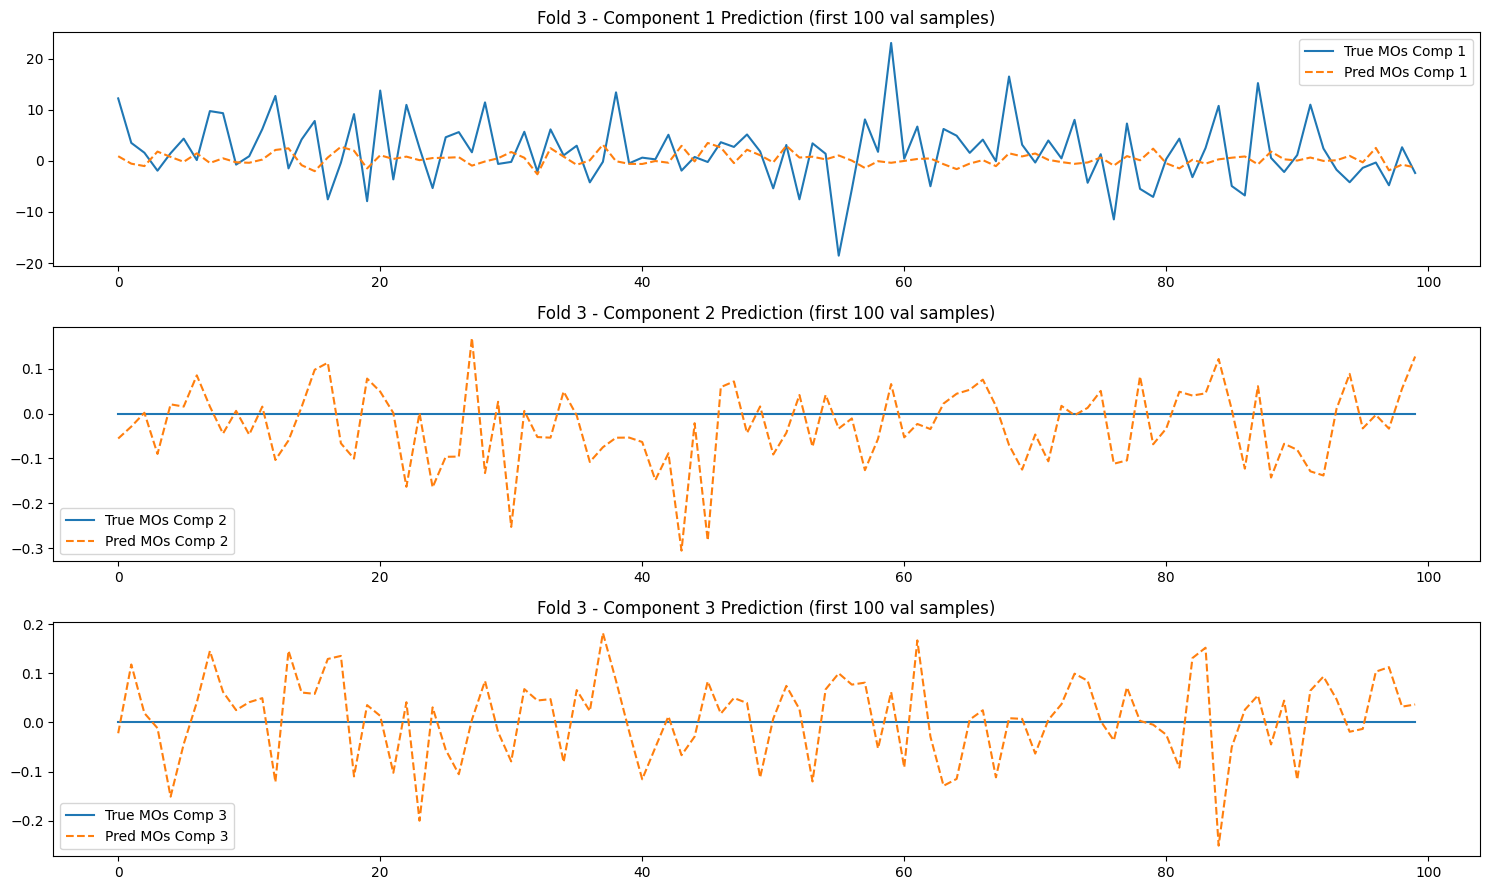


--- FOLD 4/5 ---
  Upsampling Older mice: from 727 to 1116 samples (by repetition).
  X_train_fold shape (after upsampling): (2232, 50, 10), Y_train_fold shape (after upsampling): (2232, 5)
  X_val_fold shape: (455, 50, 10), Y_val_fold shape: (455, 5)
  Unique groups in training data for fold 4: [ 3  7 11 21 24 25 38]
  Unique groups in validation data for fold 4: [ 0 13]


Model: "bidirectional_lstm_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_reg (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,805 (1.21 MB)

 Trainable params: 316,037 (1.21 MB)

 Non-trainable params: 768 (3.00 KB)

Training model for fold 4...
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 10.4860 - mean_absolute_error: 1.7549 - mean_squared_error: 10.4860 - val_loss: 16.0103 - val_mean_absolute_error: 1.4266 - val_mean_squared_error: 16.0103
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 9.4682 - mean_absolute_error: 1.5279 - mean_squared_error: 9.4682 - val_loss: 15.8827 - val_mean_absolute_error: 1.4205 - val_mean_squared_error: 15.8827
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.3291 - mean_absolute_error: 1.4495 - mean_squared_error: 9.3291 - val_loss: 15.7490 - val_mean_absolute_error: 1.4332 - val_mean_squared_error: 15.7490
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 9.0651 - mean_absolute_error: 1.3743 - mean_squared_error: 9.0651 - val_loss: 15.8347 - val_mean_absolute_error: 1.4319 - val_mean_squared_error: 15.8347
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.8258 - mean_absolute_error: 1.3211 - mean_squared_e

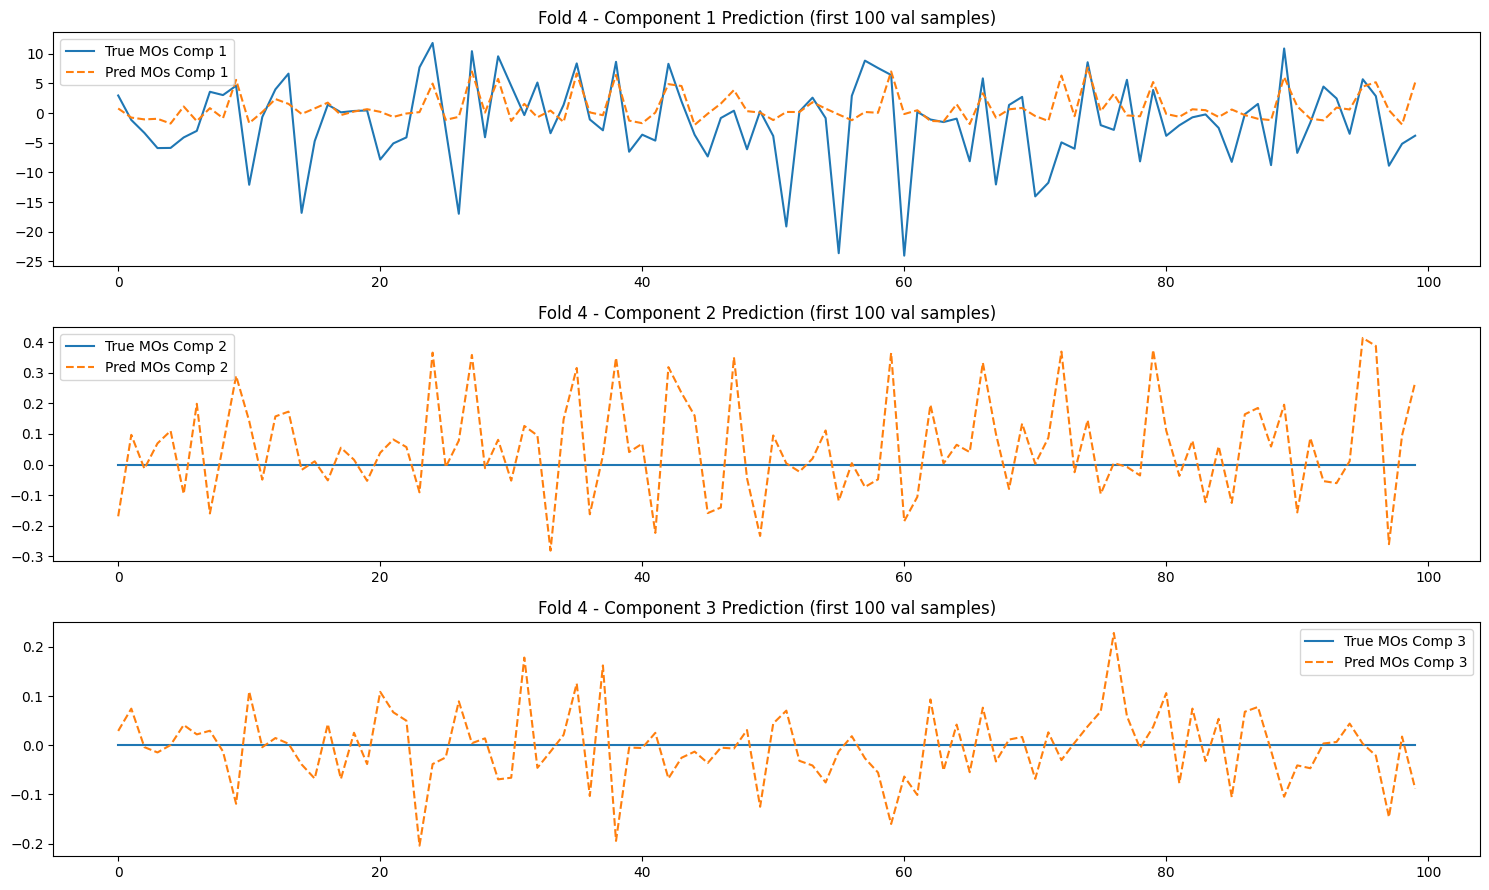


--- FOLD 5/5 ---
  Upsampling Older mice: from 522 to 1343 samples (by repetition).
  X_train_fold shape (after upsampling): (2686, 50, 10), Y_train_fold shape (after upsampling): (2686, 5)
  X_val_fold shape: (433, 50, 10), Y_val_fold shape: (433, 5)
  Unique groups in training data for fold 5: [ 0  3 11 13 21 25 38]
  Unique groups in validation data for fold 5: [ 7 24]


Model: "bidirectional_lstm_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       142,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_reg (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,805 (1.21 MB)

 Trainable params: 316,037 (1.21 MB)

 Non-trainable params: 768 (3.00 KB)

Training model for fold 5...
Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 11.2129 - mean_absolute_error: 1.8011 - mean_squared_error: 11.2129 - val_loss: 6.0781 - val_mean_absolute_error: 0.8956 - val_mean_squared_error: 6.0781
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 10.0515 - mean_absolute_error: 1.5408 - mean_squared_error: 10.0515 - val_loss: 6.1468 - val_mean_absolute_error: 0.8971 - val_mean_squared_error: 6.1468
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 9.5171 - mean_absolute_error: 1.4415 - mean_squared_error: 9.5171 - val_loss: 6.1878 - val_mean_absolute_error: 0.9054 - val_mean_squared_error: 6.1878
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 9.4011 - mean_absolute_error: 1.3787 - mean_squared_error: 9.4011 - val_loss: 6.2657 - val_mean_absolute_error: 0.9239 - val_mean_squared_error: 6.2657
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 9.2471 - mean_absolute_error: 1.3186 - mean_squared_error: 

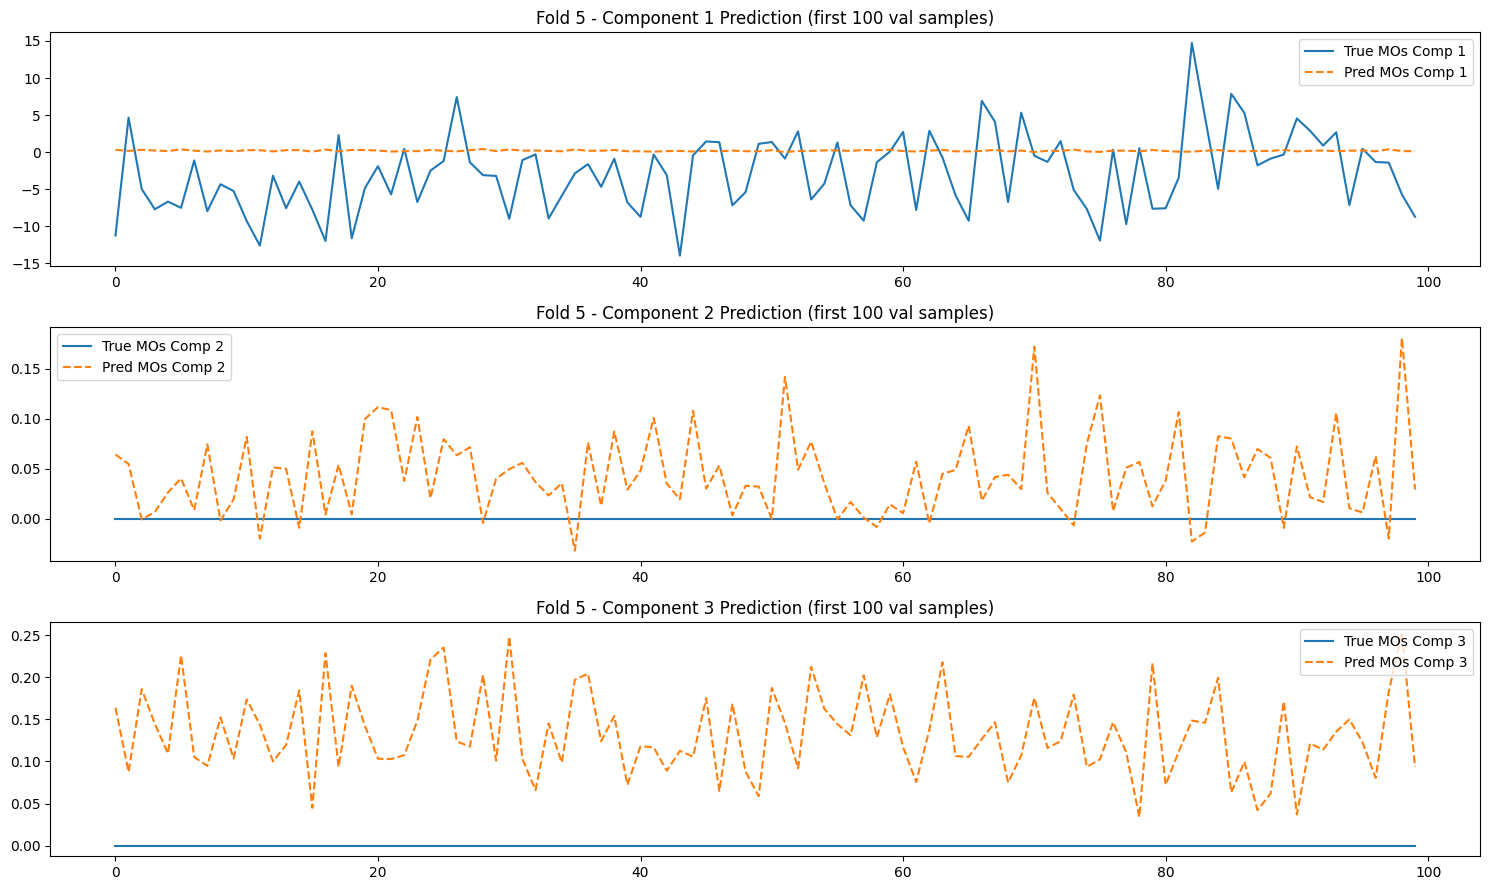

In [7]:
# Cell 7: Model Definition, CV Loop, Training, and Evaluation\nif X_final.shape[0] == 0 or Y_final.shape[0] == 0:
#raise ValueError("X_final or Y_final data is empty. Cannot proceed.")
if X_final.shape[2] == 0:
    raise ValueError(f"Number of features in X_final is 0 (Shape: {X_final.shape}). Cannot proceed.")

input_shape_model = (X_final.shape[1], X_final.shape[2]) # (n_timesteps_x, n_features_x)
output_dim_model = Y_final.shape[1] # N_PCA_COMPONENTS_Y or 1 if averaged raw Y

gkf = GroupKFold(n_splits=N_SPLITS_CV)
fold_histories = []
fold_val_mse = []
fold_val_mae = []

all_y_true_val_folds = []
all_y_pred_val_folds = []
all_age_categories_val_folds = []

print(f"Input shape for model: {input_shape_model}")
print(f"Output dimension for model: {output_dim_model}")

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_final, Y_final, groups)):
    print(f'\n--- FOLD {fold+1}/{N_SPLITS_CV} ---')
    X_train_fold, X_val_fold = X_final[train_idx], X_final[val_idx]
    Y_train_fold, Y_val_fold = Y_final[train_idx], Y_final[val_idx]
    age_cat_train_fold, age_cat_val_fold = age_categories_arr[train_idx], age_categories_arr[val_idx]
    names_train_fold, names_val_fold = mouse_names_arr[train_idx], mouse_names_arr[val_idx]
    groups_train_fold, groups_val_fold = groups[train_idx], groups[val_idx]
    
    # Apply upsampling to the current training fold if enabled
    X_train_fold_proc, Y_train_fold_proc, _, _, _ = upsample_minority_age_group(
        X_train_fold, Y_train_fold, age_cat_train_fold, names_train_fold, groups_train_fold
    )
    
    print(f'  X_train_fold shape (after upsampling): {X_train_fold_proc.shape}, Y_train_fold shape (after upsampling): {Y_train_fold_proc.shape}')
    print(f'  X_val_fold shape: {X_val_fold.shape}, Y_val_fold shape: {Y_val_fold.shape}')
    print(f'  Unique groups in training data for fold {fold+1}: {np.unique(groups_train_fold)}')
    print(f'  Unique groups in validation data for fold {fold+1}: {np.unique(groups_val_fold)}')
    
    tf.keras.backend.clear_session()
    
    model = Sequential([
        Input(shape=input_shape_model, name='input_layer'),
        Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True, name='bidir_lstm_1')),
        BatchNormalization(name='bn_1'),
        Dropout(DROPOUT_RATE, name='dropout_1'),
        Bidirectional(LSTM(LSTM_UNITS_2, return_sequences=False, name='bidir_lstm_2')), # return_sequences=False for last LSTM before Dense
        BatchNormalization(name='bn_2'),
        Dropout(DROPOUT_RATE, name='dropout_2'),
        Dense(DENSE_UNITS_REG, activation='relu', name='dense_reg'),
        Dropout(DROPOUT_RATE, name='dropout_3'),
        Dense(output_dim_model, activation='linear', name='output_dense') # Linear activation for regression
    ], name="bidirectional_lstm_regression_model")

    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='mean_squared_error', # MSE for regression
                  metrics=['mean_absolute_error', 'mean_squared_error'])
    
    model.summary()
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, verbose=1, restore_best_weights=True)
    
    print(f'Training model for fold {fold+1}...')
    history = model.fit(X_train_fold_proc, Y_train_fold_proc,
                        epochs=N_EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_data=(X_val_fold, Y_val_fold),
                        callbacks=[early_stopping],
                        verbose=1)
    fold_histories.append(history)
    
    val_loss, val_mae, val_mse_metric = model.evaluate(X_val_fold, Y_val_fold, verbose=0)
    print(f'\nEvaluating fold {fold+1} on its validation set:')
    print(f'  Fold {fold+1} Val Loss (MSE from evaluate): {val_loss:.4f}') # This is the primary loss
    print(f'  Fold {fold+1} Val MAE: {val_mae:.4f}')
    print(f'  Fold {fold+1} Val MSE (from metrics): {val_mse_metric:.4f}')
    fold_val_mse.append(val_loss) # Store the loss which is MSE
    fold_val_mae.append(val_mae)
    
    y_pred_val_fold = model.predict(X_val_fold)
    all_y_true_val_folds.append(Y_val_fold)
    all_y_pred_val_folds.append(y_pred_val_fold)
    all_age_categories_val_folds.append(age_cat_val_fold)
    
    r2 = r2_score(Y_val_fold, y_pred_val_fold)
    print(f'  Fold {fold+1} Val R-squared: {r2:.4f}')
    
    # Plot example predictions for a few components if Y is multi-dimensional
    if output_dim_model > 1:
        num_components_to_plot = min(3, output_dim_model)
        plt.figure(figsize=(15, 3 * num_components_to_plot))
        for i in range(num_components_to_plot):
            plt.subplot(num_components_to_plot, 1, i + 1)
            plt.plot(Y_val_fold[:100, i], label=f'True MOs Comp {i+1}')
            plt.plot(y_pred_val_fold[:100, i], label=f'Pred MOs Comp {i+1}', linestyle='--')
            plt.title(f'Fold {fold+1} - Component {i+1} Prediction (first 100 val samples)')
            plt.legend()
        plt.tight_layout()
        plt.show()
    else: # Single output dimension
        plt.figure(figsize=(10, 4))
        plt.plot(Y_val_fold[:100, 0], label='True MOs Activity')
        plt.plot(y_pred_val_fold[:100, 0], label='Predicted MOs Activity', linestyle='--')
        plt.title(f'Fold {fold+1} - Prediction (first 100 val samples)')
        plt.legend()
        plt.show()

## Cross-Validation Summary and Age-Based Performance Evaluation



--- Cross-Validation Summary ---
Average Validation MSE across 5 folds: 9.4081 (+/- 3.8552)
Average Validation MAE across 5 folds: 1.0427 (+/- 0.2253)


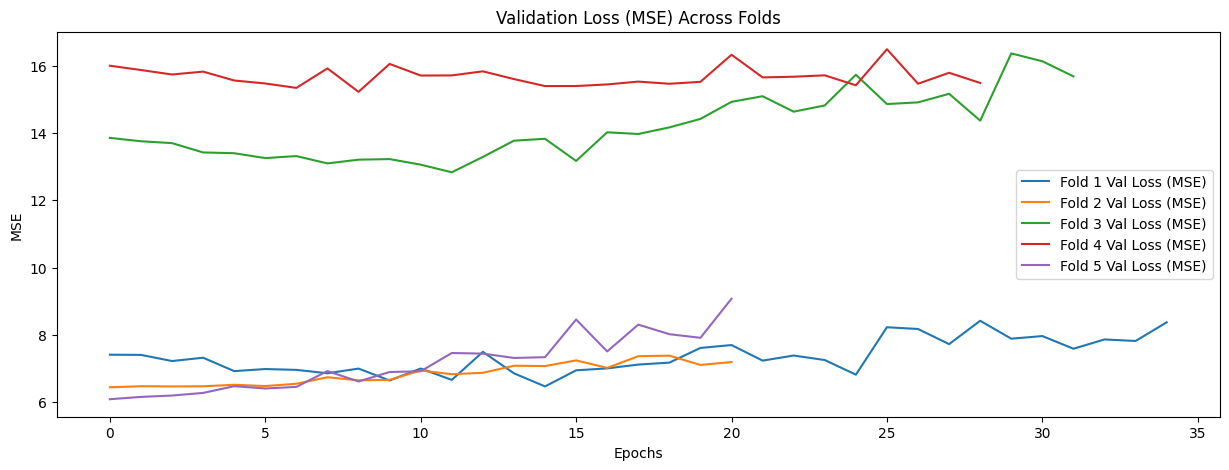


Overall R-squared on concatenated CV validation data: 0.0113

--- Performance by Age Category (on all CV validation samples) ---
  Category: Younger (Samples: 1571)
    MSE: 10.5419, MAE: 1.0794, R-squared: 0.0155
  Category: Older (Samples: 727)
    MSE: 7.4360, MAE: 0.9971, R-squared: -0.0048


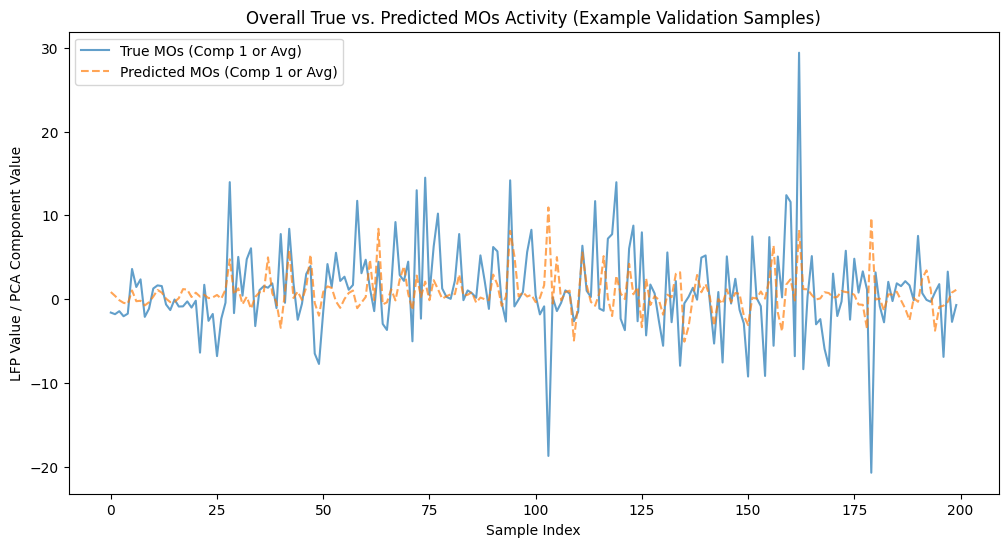


Script analysis section completed.


In [9]:
# Cell 8: Results Aggregation and Age-Based Evaluation
print("\n\n--- Cross-Validation Summary ---")
if fold_val_mse:
    print(f"Average Validation MSE across {N_SPLITS_CV} folds: {np.nanmean(fold_val_mse):.4f} (+/- {np.nanstd(fold_val_mse):.4f})")
    print(f"Average Validation MAE across {N_SPLITS_CV} folds: {np.nanmean(fold_val_mae):.4f} (+/- {np.nanstd(fold_val_mae):.4f})")
else:
    print("No validation metrics recorded. Check the training loop.")
    
# Plot training histories (loss) across folds
if fold_histories:
    plt.figure(figsize=(15, 5))
    for i, history_fold in enumerate(fold_histories):
        plt.plot(history_fold.history['val_loss'], label=f'Fold {i+1} Val Loss (MSE)')
    plt.title('Validation Loss (MSE) Across Folds')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()
else:
    print("No training histories recorded to plot.")
    
# Concatenate all validation predictions and true values
if all_y_true_val_folds and all_y_pred_val_folds and all_age_categories_val_folds:
    Y_true_all_cv = np.concatenate(all_y_true_val_folds, axis=0)
    Y_pred_all_cv = np.concatenate(all_y_pred_val_folds, axis=0)
    age_cat_all_cv = np.concatenate(all_age_categories_val_folds, axis=0)
    
    if Y_true_all_cv.shape[0] > 1: # R2 score needs at least 2 samples
        print(f'\nOverall R-squared on concatenated CV validation data: {r2_score(Y_true_all_cv, Y_pred_all_cv):.4f}')
    else:
        print(f'\nOverall R-squared on concatenated CV validation data: Not enough samples to calculate (Samples: {Y_true_all_cv.shape[0]})')

    # Performance by Age Category
    print("\n--- Performance by Age Category (on all CV validation samples) ---")
    for category in ['Younger', 'Older']:
        cat_indices = (age_cat_all_cv == category)
        if np.any(cat_indices):
            y_true_cat = Y_true_all_cv[cat_indices]
            y_pred_cat = Y_pred_all_cv[cat_indices]
            if len(y_true_cat) > 1: # R2 score needs at least 2 samples
                mse_cat = mean_squared_error(y_true_cat, y_pred_cat)
                mae_cat = mean_absolute_error(y_true_cat, y_pred_cat)
                r2_cat = r2_score(y_true_cat, y_pred_cat)
                print(f'  Category: {category} (Samples: {len(y_true_cat)})')
                print(f'    MSE: {mse_cat:.4f}, MAE: {mae_cat:.4f}, R-squared: {r2_cat:.4f}')
            else:
                print(f'  Category: {category} (Samples: {len(y_true_cat)}) - Not enough samples for R2 score.')
                mse_cat = mean_squared_error(y_true_cat, y_pred_cat)
                mae_cat = mean_absolute_error(y_true_cat, y_pred_cat)
                print(f'    MSE: {mse_cat:.4f}, MAE: {mae_cat:.4f}')
        else:
            print(f'  Category: {category} - No samples in validation set.')
            
    # Example plot of true vs predicted for a few samples, for first component if Y is multi-dimensional
    if Y_true_all_cv.shape[0] > 0:
        plt.figure(figsize=(12, 6))
        plot_samples = min(200, Y_true_all_cv.shape[0])
        component_to_plot = 0 # Plot the first component if Y is multi-dimensional
        plt.plot(Y_true_all_cv[:plot_samples, component_to_plot], label=f'True MOs (Comp {component_to_plot+1} or Avg)', alpha=0.7)
        plt.plot(Y_pred_all_cv[:plot_samples, component_to_plot], label=f'Predicted MOs (Comp {component_to_plot+1} or Avg)', linestyle='--', alpha=0.7)
        plt.title('Overall True vs. Predicted MOs Activity (Example Validation Samples)')
        plt.xlabel('Sample Index')
        plt.ylabel('LFP Value / PCA Component Value')
        plt.legend()
        plt.show()
    else:
        print("No validation samples available to plot true vs. predicted.")
# Removed blank line before this 'else' to fix SyntaxError
else:
    print("No validation predictions recorded to aggregate or plot by age.")
    
print("\nScript analysis section completed.")